# Predicting cloud-root SW and $\alpha$ from shadow geometry

The 3D cloud-root mean surface SW decomposes into a shadowed contribution and an unshadowed
contribution:

$$\langle\mathrm{SW}_\downarrow\rangle_{\mathrm{cr,3D}} \;=\; f_{\mathrm{sh}}\,\widehat{\mathrm{SW}}_{\mathrm{sh}}
  \;+\; (1 - f_{\mathrm{sh}})\,\widehat{\mathrm{SW}}_{\mathrm{out}}$$

where both partition aggregators are **means over domain-wide subsets defined by a single
threshold on the SW field**:

$$\widehat{\mathrm{SW}}_{\mathrm{sh}} = \big\langle\mathrm{SW}_\downarrow\big\rangle_{\mathrm{SW}_\downarrow \,<\, \mathrm{SW}_{\mathrm{clr}}},
\qquad
\widehat{\mathrm{SW}}_{\mathrm{out}} = \big\langle\mathrm{SW}_\downarrow\big\rangle_{\mathrm{SW}_\downarrow \,>\, \mathrm{SW}_{\mathrm{clr}}}.$$

Two design choices matter:

1. **Mean, not median.** Shadow-side SW is heavy-tailed toward low values (deep shadows drag
   the median down relative to the mean). Using mean consistently on both sides preserves the
   total-flux budget and is strictly more accurate for the $\alpha$ closure than any
   mean/median mix.
2. **Domain-wide, not cloud-root.** Both subsets are defined on the full SW field without a
   cloud mask, so observations that lack a cloud diagnostic (surface SW stations, geostationary
   sensors) can reproduce these aggregators directly. The downstream α chain is validated
   against LES with the cloud-mask-free definitions.

To close the loop from observations to the radiative-coupling parameter $\alpha$ we need:

1. $\widehat{\mathrm{SW}}_{\mathrm{sh}}$ and $\widehat{\mathrm{SW}}_{\mathrm{out}}$ — from the surface SW field and the clear-sky reference.
2. $f_{\mathrm{sh}}$ — the cloud-root shadow fraction, predicted below from $f_{\mathrm{sh}}^{\mathrm{dom}}$, $c_f$, $\mu_0$.
3. $\alpha$ — from the $\beta$ partitioning framework applied to the cloud-root net radiation perturbation.


In [1]:
import sys
import pickle as _pkl
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr

sys.path.insert(0, str(Path.cwd()))
from cass_analysis import load_sfc_sw_dn, sim_time_to_lst, RunSet
from catalog import make_runset, CASS_ROOT

CACHE_DIR = CASS_ROOT / 'analysis'
LST_LO, LST_HI = 11.5, 17.0
EXPT_KEY = 'no_aerosols_zero_wind'

In [2]:
# ── Load caches ──────────────────────────────────────────────────────────────
# v2 caches use shadow definition SW_dn < SW_clr (no arbitrary 0.7 threshold).
with open(CACHE_DIR / 'f_shadow_cache_v2.pkl', 'rb') as f:
    shadow_reps = _pkl.load(f)

with open(CACHE_DIR / 'radcoupling_cache.pkl', 'rb') as f:
    rc = _pkl.load(f)

# New: domain-wide mean(SW|shadow) and mean(SW|sunlit) aggregators, per rep,
# built by test_sw_aggregate_variants.py. Obs-compatible (no cloud mask).
with open(CACHE_DIR / 'sw_agg_variants_cache.pkl', 'rb') as f:
    sw_agg_reps = _pkl.load(f)

def ens_mean(reps, keys):
    m, s = {}, {}
    for k in keys:
        stack = np.stack([r[k] for r in reps])
        m[k] = np.nanmean(stack, axis=0)
        s[k] = np.nanstd(stack, axis=0)
    return m, s

# Shadow diagnostics (v2 — shadow is SW_dn < SW_clr).
# Note: sw_shadow / sw_outside / sw_above_clr_p50 in this cache are the OLD
# aggregators (mixed mean/median, cloud-root conditional). Kept only for
# back-compat; the new mean+mean (any) aggregators come from sw_agg_variants.
sh_keys = ['f_shadow', 'f_sh_domain', 'sw_clear', 'cf']
sh_m, sh_s = ens_mean(shadow_reps, sh_keys)
lst = shadow_reps[0]['lst']
sza = shadow_reps[0]['sza']
mu0 = np.cos(np.radians(sza))

# Domain-wide aggregators (mean | shadow) and (mean | sunlit) — ensemble-mean.
agg_keys = ['SW_sh_mean_any', 'SW_out_mean_any']
agg_m, _ = ens_mean(sw_agg_reps, agg_keys)
sw_sh_hat  = agg_m['SW_sh_mean_any']      # mean over SW_dn < SW_clr (domain-wide)
sw_out_hat = agg_m['SW_out_mean_any']     # mean over SW_dn > SW_clr (domain-wide)

rc_keys = ['sw_dn_cr', 'sw_dn_dm']
rc1d_m, _ = ens_mean(rc['1D'], rc_keys)
rc3d_m, _ = ens_mean(rc['3D'], rc_keys)

cf       = sh_m['cf']
sw_clr   = sh_m['sw_clear']
sw_cr_1d = rc1d_m['sw_dn_cr']
sw_cr_3d = rc3d_m['sw_dn_cr']
f_sh     = sh_m['f_shadow']
f_sh_dom = sh_m['f_sh_domain']

win = (lst >= LST_LO) & (lst <= LST_HI) & np.isfinite(f_sh)


/tmp/ipykernel_528072/3020828603.py:18: RuntimeWarning: Mean of empty slice
  m[k] = np.nanmean(stack, axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [3]:
# Cache sanity check — use the new aggregators
print(f'CASS: f_sh range            {np.nanmin(f_sh[win]):.3f} - {np.nanmax(f_sh[win]):.3f}')
print(f'CASS: f_dom range           {np.nanmin(f_sh_dom[win]):.3f} - {np.nanmax(f_sh_dom[win]):.3f}')
print(f'CASS: cf range              {np.nanmin(cf[win]):.3f} - {np.nanmax(cf[win]):.3f}')
print(f'CASS: SW_clr                mean {np.nanmean(sw_clr[win]):6.0f} W/m²')
print(f'CASS: mean(SW | SW<SW_clr)  mean {np.nanmean(sw_sh_hat[win]):6.0f} W/m²   [shadow side]')
print(f'CASS: mean(SW | SW>SW_clr)  mean {np.nanmean(sw_out_hat[win]):6.0f} W/m²   [sunlit side]')


CASS: f_sh range            0.008 - 0.392
CASS: f_dom range           0.032 - 0.208
CASS: cf range              0.008 - 0.174
CASS: SW_clr                mean    860 W/m²
CASS: mean(SW | SW<SW_clr)  mean    329 W/m²   [shadow side]
CASS: mean(SW | SW>SW_clr)  mean    987 W/m²   [sunlit side]


## Cloud-root SW: the raw data

The black curve is the 3D cloud-root mean $\langle\mathrm{SW}_\downarrow\rangle_{\mathrm{cr,3D}}$ from the LES, 11:30–17:00 LST. The
red curve is the 1D radiation counterpart: same atmosphere and sun, but with the 1D radiation
scheme rather than the ray tracer. The gap between them is what the $\alpha$ closure needs to
reproduce.


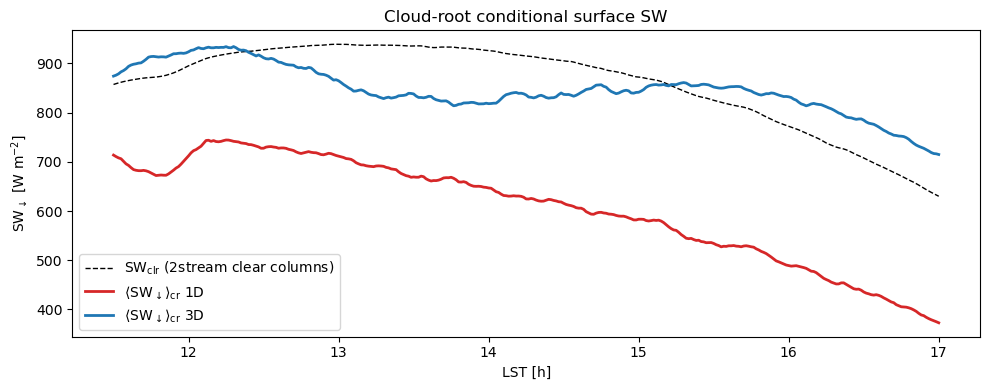

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(lst[win], sw_clr[win], 'k--', lw=1,
        label=r'$\mathrm{SW}_{\mathrm{clr}}$ (2stream clear columns)')
ax.plot(lst[win], sw_cr_1d[win], 'C3-', lw=2,
        label=r'$\langle\mathrm{SW}_{\downarrow}\rangle_{\mathrm{cr}}$ 1D')
ax.plot(lst[win], sw_cr_3d[win], 'C0-', lw=2,
        label=r'$\langle\mathrm{SW}_{\downarrow}\rangle_{\mathrm{cr}}$ 3D')
ax.set_ylabel(r'SW$_{\downarrow}$ [W m$^{-2}$]')
ax.set_xlabel('LST [h]')
ax.set_title('Cloud-root conditional surface SW')
ax.legend()

fig.tight_layout()

## Obs-compatible partitioning: mean over the sunlit and shadowed subsets

The old notebook used $\widehat{\mathrm{SW}}_{\mathrm{out}} = \mathrm{median}(\mathrm{SW}_\downarrow \mid \mathrm{SW}_\downarrow > \mathrm{SW}_{\mathrm{clr}})$ as the sunlit aggregator
and $\widehat{\mathrm{SW}}_{\mathrm{sh}} = $ mean over **cloud-root** shaded columns as the shadow aggregator. That was a
mean/median mix with a cloud-mask dependence on the shadow side.

The replacement is consistent and obs-compatible:

$$\widehat{\mathrm{SW}}_{\mathrm{sh}} = \big\langle\mathrm{SW}_\downarrow\big\rangle_{\mathrm{SW}_\downarrow \,<\, \mathrm{SW}_{\mathrm{clr}}},
\qquad
\widehat{\mathrm{SW}}_{\mathrm{out}} = \big\langle\mathrm{SW}_\downarrow\big\rangle_{\mathrm{SW}_\downarrow \,>\, \mathrm{SW}_{\mathrm{clr}}}.$$

**Why mean and not median on both sides?** The shadow-side SW distribution is heavy-tailed
toward low values — a few deeply shadowed columns pull the median well below the mean
(CASS window medians: $\mathrm{mean}\!=\!340$, $\mathrm{median}\!=\!228$ W m⁻²). The sunlit side
is roughly symmetric so mean $\approx$ median there. Mean is the flux-conserving quantity: the
total surface-integrated $\mathrm{SW}_\downarrow$ really is $f_{\mathrm{sh}}\cdot\widehat{\mathrm{SW}}_{\mathrm{sh}} + (1-f_{\mathrm{sh}})\cdot\widehat{\mathrm{SW}}_{\mathrm{out}}$ for the
mean aggregator; it isn't for median.

**Why drop the cloud-root restriction on the shadow side?** Observations may lack a cloud
diagnostic (ground-based surface SW networks, geostationary sensors without coincident cloud
retrievals). A threshold on the SW field alone is reproducible anywhere. The tradeoff: some
shadowed columns may not be directly under clouds (adjacent column shadows at moderate SZA).
Empirically the α-closure is slightly better with the domain-wide definition than with the
cloud-root one, because the mean+mean scheme is flux-conserving when applied to the same
partition.


## Prediction for $\langle\mathrm{SW}_\downarrow\rangle_{\mathrm{cr,3D}}$

With the mean+mean aggregators the cloud-root SW prediction is exactly

$$\langle\mathrm{SW}_\downarrow\rangle_{\mathrm{cr,3D}}^{\mathrm{pred}} \;=\; f_{\mathrm{sh}}\,\widehat{\mathrm{SW}}_{\mathrm{sh}} + (1-f_{\mathrm{sh}})\,\widehat{\mathrm{SW}}_{\mathrm{out}}.$$

The naive alternative ($\widehat{\mathrm{SW}}_{\mathrm{out}} = \mathrm{SW}_{\mathrm{clr}}$) ignores the 3D cloud-side
enhancement of the sunlit side and systematically under-predicts.


In [5]:
# Mean+mean (domain-wide) partitioning — the operational prediction
sw_cr_3d_pred  = f_sh * sw_sh_hat + (1 - f_sh) * sw_out_hat

# Naive: ignore the sunlit 3D enhancement
sw_cr_3d_naive = f_sh * sw_sh_hat + (1 - f_sh) * sw_clr


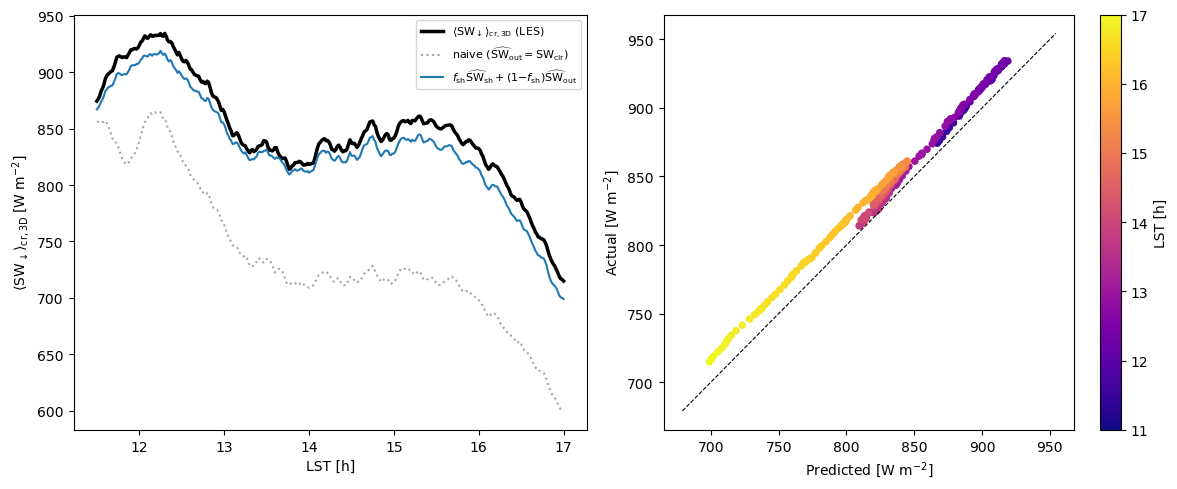

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Time series
ax = axes[0]
ax.plot(lst[win], sw_cr_3d[win],        'k-',  lw=2.5,
        label=r'$\langle\mathrm{SW}_\downarrow\rangle_{\mathrm{cr,3D}}$ (LES)')
ax.plot(lst[win], sw_cr_3d_naive[win], 'C7:', lw=1.5, alpha=0.7,
        label=r'naive ($\widehat{\mathrm{SW}}_{\mathrm{out}}=\mathrm{SW}_{\mathrm{clr}}$)')
ax.plot(lst[win], sw_cr_3d_pred[win],  'C0-', lw=1.5,
        label=r'$f_{\mathrm{sh}}\widehat{\mathrm{SW}}_{\mathrm{sh}} + (1{-}f_{\mathrm{sh}})\widehat{\mathrm{SW}}_{\mathrm{out}}$')
ax.set(xlabel='LST [h]', ylabel=r'$\langle\mathrm{SW}_\downarrow\rangle_{\mathrm{cr,3D}}$ [W m$^{-2}$]',
       )
ax.legend(fontsize=8)

# (b) Scatter
ax = axes[1]
ok = win & np.isfinite(sw_cr_3d_pred) & np.isfinite(sw_cr_3d)
sc = ax.scatter(sw_cr_3d_pred[ok], sw_cr_3d[ok], c=lst[ok], s=20,
                cmap='plasma', vmin=11, vmax=17)

lo = min(np.nanmin(sw_cr_3d_pred[ok]), np.nanmin(sw_cr_3d[ok]))
hi = max(np.nanmax(sw_cr_3d_pred[ok]), np.nanmax(sw_cr_3d[ok]))
lims = [lo - 20, hi + 20]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set(xlabel='Predicted [W m$^{-2}$]', ylabel='Actual [W m$^{-2}$]')

fig.colorbar(sc, ax=ax, label='LST [h]')

fig.tight_layout()


In [7]:
ok = win & np.isfinite(sw_cr_3d) & np.isfinite(f_sh) & np.isfinite(sw_sh_hat)

def stats(pred, actual, label):
    finite = np.isfinite(pred) & np.isfinite(actual)
    r, _ = pearsonr(pred[finite], actual[finite])
    bias = np.mean(pred[finite] - actual[finite])
    rmse = np.sqrt(np.mean((pred[finite] - actual[finite])**2))
    print(f'{label:<50} r={r:.3f}  bias={bias:+7.1f}  RMSE={rmse:6.1f} W/m²')

print('Predicting <SW_dn>_cr,3D (mean+mean, domain-wide):\n')
stats(sw_cr_3d_naive[ok], sw_cr_3d[ok], 'Naive  (SW_out_hat = SW_clr)')
stats(sw_cr_3d_pred[ok],  sw_cr_3d[ok], 'mean+mean  partitioning')


Predicting <SW_dn>_cr,3D (mean+mean, domain-wide):

Naive  (SW_out_hat = SW_clr)                       r=0.952  bias= -109.5  RMSE= 112.0 W/m²
mean+mean  partitioning                            r=0.996  bias=  -13.5  RMSE=  14.2 W/m²


## Summary

In [8]:
ok = win & np.isfinite(sw_cr_3d) & np.isfinite(sw_cr_3d_pred)

r_pred, _ = pearsonr(sw_cr_3d_pred[ok], sw_cr_3d[ok])
bias_pred = np.mean(sw_cr_3d_pred[ok] - sw_cr_3d[ok])
rmse_pred = np.sqrt(np.mean((sw_cr_3d_pred[ok] - sw_cr_3d[ok])**2))

r_naive, _ = pearsonr(sw_cr_3d_naive[ok], sw_cr_3d[ok])
bias_naive = np.mean(sw_cr_3d_naive[ok] - sw_cr_3d[ok])
rmse_naive = np.sqrt(np.mean((sw_cr_3d_naive[ok] - sw_cr_3d[ok])**2))

print(f'Naive       (SW_out_hat = SW_clr):            '
      f'r={r_naive:.3f}  bias={bias_naive:+.1f}  RMSE={rmse_naive:.1f} W/m²')
print(f'mean+mean   (domain-wide):                    '
      f'r={r_pred:.3f}  bias={bias_pred:+.1f}  RMSE={rmse_pred:.1f} W/m²')

print(f'\n--- Component values (window mean) ---')
print(f'  SW_clr:                                 {np.nanmean(sw_clr[ok]):7.0f} W/m²')
print(f'  SW_out_hat  = mean(SW|SW>SW_clr):       {np.nanmean(sw_out_hat[ok]):7.0f} W/m²'
      f'   ({np.nanmean(sw_out_hat[ok]/sw_clr[ok])-1:+.1%} vs SW_clr)')
print(f'  SW_sh_hat   = mean(SW|SW<SW_clr):       {np.nanmean(sw_sh_hat[ok]):7.0f} W/m²')
print(f'  f_shadow    = cloud-root shadow frac:   {np.nanmean(f_sh[ok]):7.3f}')


Naive       (SW_out_hat = SW_clr):            r=0.952  bias=-109.5  RMSE=112.0 W/m²
mean+mean   (domain-wide):                    r=0.996  bias=-13.5  RMSE=14.2 W/m²

--- Component values (window mean) ---
  SW_clr:                                     860 W/m²
  SW_out_hat  = mean(SW|SW>SW_clr):           987 W/m²   (+14.9% vs SW_clr)
  SW_sh_hat   = mean(SW|SW<SW_clr):           329 W/m²
  f_shadow    = cloud-root shadow frac:     0.222


# Predicting $f_{\mathrm{sh}}$ from $f_{\mathrm{sh}}^{\mathrm{dom}}$, $c_f$, and $\mu_0$

We need to predict the **cloud-root shadow fraction** $f_{\mathrm{sh}}$ because it enters the
$\alpha$-closure via the shadow-partitioning of $\langle\mathrm{SW}_\downarrow\rangle_{\mathrm{cr}}$. The goal is a
closed-form expression from quantities we already diagnose in the 1D model ($c_f$, $\mu_0$) and
the surface SW field ($f_{\mathrm{sh}}^{\mathrm{dom}}$).

The operational form used throughout this notebook is

$$\boxed{\;f_{\mathrm{sh}} \;=\; f_{\mathrm{sh}}^{\mathrm{dom}} \;+\; (1 - f_{\mathrm{sh}}^{\mathrm{dom}})\,c_f\,\mu_0^2\;}$$

**This is a phenomenological form, not a first-principles derivation.** The sections below
motivate the three constraints it satisfies, show the validation on CASS and Tijhuis.


## Shadow definition and the quantity

A surface column $(x,y)$ is *shadowed* iff

$$\mathrm{SW}_\downarrow(x,y) \;<\; \mathrm{SW}_{\mathrm{clr}}(x,y)$$

where $\mathrm{SW}_\downarrow$ is the **total** (direct + diffuse) surface downwelling SW and
$\mathrm{SW}_{\mathrm{clr}}$ is the clear-sky reference at the same column (same atmosphere, same Sun,
no cloud). The **total** matters: for optically thin warm clouds, most of the attenuated
direct beam is forward-scattered and reappears in the downward flux — $\mathrm{SW}_\downarrow$ stays
close to $\mathrm{SW}_{\mathrm{clr}}$ even when the direct beam has been heavily reduced.

From this, two quantities are measured:

- $f_{\mathrm{sh}}^{\mathrm{dom}}$ — fraction of the *entire domain* whose $\mathrm{SW}_\downarrow < \mathrm{SW}_{\mathrm{clr}}$.
  Observable from the SW field alone.
- $f_{\mathrm{sh}}$ — fraction of *cloud-root* columns (LWP > 0) whose $\mathrm{SW}_\downarrow < \mathrm{SW}_{\mathrm{clr}}$.
  The quantity we predict.


## The three constraints the form must satisfy

The operational form is constructed to respect three physical limits:

**(1) Random-overlap lower bound.**  If cloud and shadow were spatially uncorrelated in the
domain, a random cloud-root column would coincide with a shadow with probability equal to the
domain shadow fraction $f_{\mathrm{sh}}^{\mathrm{dom}}$. Clouds *cause* shadows, so cloud and shadow are
positively correlated — the uncorrelated case is the lower bound:
$$f_{\mathrm{sh}} \;\geq\; f_{\mathrm{sh}}^{\mathrm{dom}}.$$
The form separates $f_{\mathrm{sh}}$ into the floor plus an excess, and only the excess needs
modelling.

**(2) Excess must vanish as $c_f\to 0$.**  With no clouds there is no self-shadow contribution
on top of the random-overlap floor. The excess must therefore carry at least one factor of
$c_f$. The simplest choice is *linear* in $c_f$, which is what the baseline does.

**(3) Excess must vanish as $\mu_0\to 0$.**  At grazing Sun the shadow from any single cloud is
displaced far from the cloud-root column itself (by $h\tan\theta$, large) and there is no
preferential self-shadow beyond the random-overlap floor. The excess must carry at least one
factor that goes to zero with $\mu_0$.  And at $\mu_0\to 1$ (overhead), the excess should peak —
every cloud-root column receives its own column's attenuation. $\mu_0^2$ is the minimum-
complexity choice with the right endpoints and smooth monotone behavior; $\mu_0^n$ for $n\in[1,3]$
gives a visually similar curve and **the data do not distinguish between them strongly**. The
$n=2$ choice is empirical.

Combining (1)–(3) with the bound $f_{\mathrm{sh}}\leq 1$ (implemented via the $(1-f_{\mathrm{sh}}^{\mathrm{dom}})$ multiplier
so the form is strictly in $[f_{\mathrm{sh}}^{\mathrm{dom}}, 1]$) gives the baseline:

$$f_{\mathrm{sh}} = f_{\mathrm{sh}}^{\mathrm{dom}} + (1-f_{\mathrm{sh}}^{\mathrm{dom}})\cdot c_f\cdot \mu_0^2.$$

**This is not a derivation** — it is the simplest form consistent with the limits. Its
validity is established empirically, not analytically.


In [9]:
# ── Load Tijhuis v2 cache (220 cumulus scenes, independent validation set) ──
with open(CACHE_DIR / 'tijhuis_cache_v2.pkl', 'rb') as f:
    tij = _pkl.load(f)

# ── Baseline f_sh prediction ─────────────────────────────────────────────────
f_sh_pred_cass   = f_sh_dom             + (1 - f_sh_dom)             * cf           * mu0**2
tij['f_sh_pred'] = tij['f_sh_domain']   + (1 - tij['f_sh_domain'])   * tij['cf']    * tij['mu0']**2

def _stats(pred, obs, mask):
    m = mask & np.isfinite(pred) & np.isfinite(obs)
    p, o = pred[m], obs[m]
    r, _ = pearsonr(p, o)
    return f'r={r:+.3f}  bias={(p-o).mean():+.3f}  RMSE={np.sqrt(((p-o)**2).mean()):.3f}  n={m.sum()}'

print('Baseline  f_sh = f_sh_dom + (1 - f_sh_dom) · c_f · μ₀²')
print()
print(f'  CASS     : {_stats(f_sh_pred_cass,   f_sh,            win)}')
print(f'  Tijhuis  : {_stats(tij["f_sh_pred"], tij["f_shadow"], np.ones(220, bool))}')


Baseline  f_sh = f_sh_dom + (1 - f_sh_dom) · c_f · μ₀²

  CASS     : r=+0.866  bias=+0.023  RMSE=0.072  n=331
  Tijhuis  : r=+0.804  bias=+0.035  RMSE=0.137  n=220


## Validation on CASS + Tijhuis

Blue points are CASS (4-rep ensemble mean, 11:30–17:00 LST window). Orange squares are
Tijhuis (220 independent cumulus cloud fields × 10 SZAs each). The baseline achieves
$r\sim 0.87$ on CASS and $r\sim 0.80$ on Tijhuis with **zero fitted parameters**.


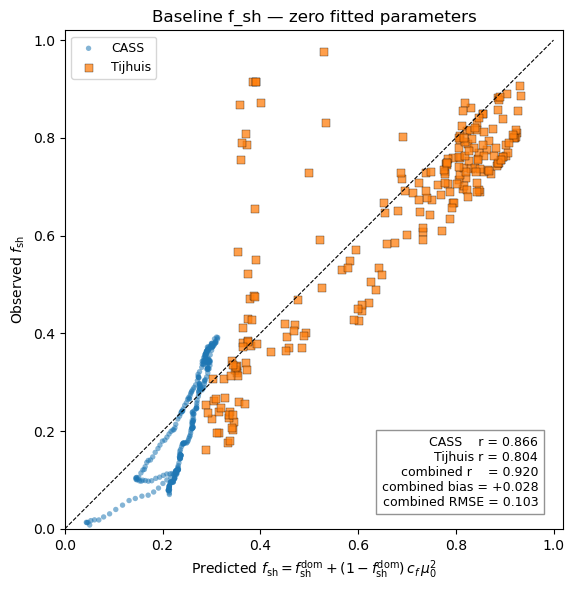

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 6))

ok_c = win & np.isfinite(f_sh) & np.isfinite(f_sh_pred_cass)
ok_t = np.isfinite(tij['f_shadow']) & np.isfinite(tij['f_sh_pred'])

ax.scatter(f_sh_pred_cass[ok_c], f_sh[ok_c], c='C0', s=15, alpha=0.55, edgecolors='none',
           label='CASS')
ax.scatter(tij['f_sh_pred'][ok_t], tij['f_shadow'][ok_t], c='C1', s=28, marker='s',
           alpha=0.75, edgecolors='k', linewidths=0.3, label='Tijhuis')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)

r_c, _ = pearsonr(f_sh_pred_cass[ok_c], f_sh[ok_c])
r_t, _ = pearsonr(tij['f_sh_pred'][ok_t], tij['f_shadow'][ok_t])
all_p = np.concatenate([f_sh_pred_cass[ok_c], tij['f_sh_pred'][ok_t]])
all_o = np.concatenate([f_sh[ok_c],            tij['f_shadow'][ok_t]])
r_a, _ = pearsonr(all_p, all_o)
rmse_a = np.sqrt(((all_p - all_o)**2).mean())
bias_a = (all_p - all_o).mean()

ax.set(xlim=(0, 1.02), ylim=(0, 1.02),
       xlabel=r'Predicted $f_{\mathrm{sh}} = f_{\mathrm{sh}}^{\mathrm{dom}} + (1-f_{\mathrm{sh}}^{\mathrm{dom}})\,c_f\,\mu_0^2$',
       ylabel=r'Observed $f_{\mathrm{sh}}$')
ax.set_title('Baseline f_sh — zero fitted parameters')
ax.set_aspect('equal')
ax.text(0.95, 0.04,
        f'CASS    r = {r_c:.3f}\nTijhuis r = {r_t:.3f}\n'
        f'combined r    = {r_a:.3f}\ncombined bias = {bias_a:+.3f}\n'
        f'combined RMSE = {rmse_a:.3f}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='grey'))
ax.legend(fontsize=9, loc='upper left')
fig.tight_layout()


## Where the form works and where it doesn't — Tijhuis by SZA bin

The baseline's failure mode is visible only when you bin Tijhuis by SZA. It is near-perfect at
SZA $>15°$ (which is most of the data including all CASS noon points) but systematically
under-predicts the overhead regime SZA $< 15°$, where the smallest $\mu_0^2$ correction cannot
reach the observed $f_{\mathrm{sh}}\to 0.9$ of optically thick overhead scenes.

This is the only regime where a more elaborate form could win — and it's a small bin (46 of
220 Tijhuis points, 0 CASS points because CASS noon is SZA ~20°). We accept the residual as
known structure, not a flaw in the form itself.


In [11]:
def _bin_stats(pred, obs, mask):
    ok = mask & np.isfinite(pred) & np.isfinite(obs)
    p, o = pred[ok], obs[ok]
    if len(p) < 3: return None
    r, _ = pearsonr(p, o)
    return dict(n=int(ok.sum()), r=r,
                bias=float((p - o).mean()), rmse=float(np.sqrt(((p - o)**2).mean())))

print(f'Tijhuis by SZA bin (baseline):')
print(f"  {'SZA bin':10s}  {'n':>4s}   {'r':>6s}   {'bias':>7s}   {'RMSE':>6s}")
print('  ' + '─'*42)
for lo, hi in [(0, 15), (15, 35), (35, 55), (55, 90)]:
    mk = (tij['sza'] >= lo) & (tij['sza'] < hi)
    s  = _bin_stats(tij['f_sh_pred'], tij['f_shadow'], mk)
    print(f"  [{lo},{hi}){'':4s}  {s['n']:4d}   {s['r']:+.3f}   {s['bias']:+.3f}   {s['rmse']:.3f}")


Tijhuis by SZA bin (baseline):
  SZA bin        n        r      bias     RMSE
  ──────────────────────────────────────────
  [0,15)        46   +0.355   -0.109   0.241
  [15,35)        60   +0.965   +0.085   0.108
  [35,55)        55   +0.983   +0.101   0.108
  [55,90)        59   +0.992   +0.034   0.044


## Closing the loop: predicting $\alpha$

$$\alpha = \frac{\widetilde{Q}_{\rho,0}^{\mathrm{cr}}}{\langle\widetilde{Q}_{\rho,0}\rangle}
  = 1 + \frac{\delta\widetilde{Q}_{\rho,0}^{\mathrm{cr}}}{\langle\widetilde{Q}_{\rho,0}\rangle}$$

The cloud-root flux perturbation connects to SW via the partitioning coefficient $\beta$:

$$\delta\widetilde{Q}_{\rho,0}^{\mathrm{cr}} = \beta \cdot \frac{(1-a)\,\delta\mathrm{SW}^{\mathrm{cr}}}{\rho\,c_p}$$

where $\beta(t) = \delta\widetilde{Q}_{\rho,0}^{\mathrm{cr}} / (\delta R_n^{\mathrm{cr}} / \rho c_p)$
is computed from the LES at each timestep (time-varying, not a constant),
$a = 0.22$, and $\delta\mathrm{SW}^{\mathrm{cr}} = \langle\mathrm{SW}\rangle_{\mathrm{cr}} - \langle\mathrm{SW}\rangle_{\mathrm{dm}}$.

So:

$$\alpha = 1 + \frac{\beta\,(1-a)\,\delta\mathrm{SW}^{\mathrm{cr}}}{\rho\,c_p\,\langle\widetilde{Q}_{\rho,0}\rangle}$$

In [12]:
from cass_analysis import eps_v, THETA_REF, rho, cp

# ── Load full radcoupling data to compute beta(t) ────────────────────────────
rc_all = ['Q_rho_dm', 'Q_rho_cr', 'sw_dn_dm', 'sw_dn_cr',
          'lw_net_dm', 'lw_net_cr', 'thl_fb_dm', 'thl_fb_cr',
          'qt_fb_dm', 'qt_fb_cr']
rc1d_all, _ = ens_mean(rc['1D'], rc_all)
rc3d_all, _ = ens_mean(rc['3D'], rc_all)

ALBEDO = 0.22
BETA_DRN_THRESH = 5.0  # W/m2

def compute_beta_alpha(rc_ens):
    """Compute beta(t) and alpha(t) from radcoupling ensemble means."""
    dQ   = rc_ens['Q_rho_cr'] - rc_ens['Q_rho_dm']
    dsw  = rc_ens['sw_dn_cr'] - rc_ens['sw_dn_dm']
    dlw  = rc_ens['lw_net_cr'] - rc_ens['lw_net_dm']
    # Net radiation perturbation: (1-a)*delta_SW + delta_LW
    dRn  = (1 - ALBEDO) * dsw + dlw  # W/m2
    dRn_kin = dRn / (rho * cp)  # K m/s

    # beta = dQ / dRn_kin (dimensionless)
    ok = np.abs(dRn) > BETA_DRN_THRESH
    beta = np.where(ok, dQ / dRn_kin, np.nan)

    # alpha = Q_cr / Q_dm
    Q_dm = rc_ens['Q_rho_dm']
    alpha = rc_ens['Q_rho_cr'] / np.where(np.abs(Q_dm) > 1e-12, Q_dm, np.nan)

    return beta, alpha, dQ, dsw, Q_dm

beta_1d, alpha_1d_actual, _, dsw_1d, Q_dm_1d = compute_beta_alpha(rc1d_all)
beta_3d, alpha_3d_actual, _, dsw_3d, Q_dm_3d = compute_beta_alpha(rc3d_all)

print(f'beta_1D mean (win): {np.nanmean(beta_1d[win]):.3f}')
print(f'beta_3D mean (win): {np.nanmean(beta_3d[win]):.3f}')


beta_1D mean (win): 0.296
beta_3D mean (win): 0.310


/tmp/ipykernel_528072/3020828603.py:18: RuntimeWarning: Mean of empty slice
  m[k] = np.nanmean(stack, axis=0)


In [13]:
# ── Predict alpha from SW + time-mean LW ─────────────────────────────────────
# Use delta_LW_1D_mean for both schemes: one constant from the cheap 1D model.

dlw_1d = rc1d_all['lw_net_cr'] - rc1d_all['lw_net_dm']
dlw_mean = np.nanmean(dlw_1d[win])
print(f'delta_LW (1D mean, used for both): {dlw_mean:.1f} W/m2')

# ── Fully-predicted 3D cloud-root SW chain ───────────────────────────────────
# Use PREDICTED f_sh (from the domain-shadow formula) instead of observed
sw_cr_3d_pred_full = f_sh_pred_cass * sw_sh_hat + (1 - f_sh_pred_cass) * sw_out_hat

# 1D: actual SW_cr
dsw_cr_1d = sw_cr_1d - rc1d_all['sw_dn_dm']
dRn_1d = (1 - ALBEDO) * dsw_cr_1d + dlw_mean
alpha_1d_pred = 1 + beta_1d * dRn_1d / (rho * cp * Q_dm_1d)

# 3D with OBSERVED f_sh (previous version)
dsw_cr_3d_pred = sw_cr_3d_pred - rc3d_all['sw_dn_dm']
dRn_3d_pred = (1 - ALBEDO) * dsw_cr_3d_pred + dlw_mean
alpha_3d_pred = 1 + beta_1d * dRn_3d_pred / (rho * cp * Q_dm_3d)

# 3D with PREDICTED f_sh (fully closed loop)
dsw_cr_3d_full = sw_cr_3d_pred_full - rc3d_all['sw_dn_dm']
dRn_3d_full = (1 - ALBEDO) * dsw_cr_3d_full + dlw_mean
alpha_3d_full = 1 + beta_1d * dRn_3d_full / (rho * cp * Q_dm_3d)

# 3D from actual SW (upper bound)
dsw_cr_3d_actual = sw_cr_3d - rc3d_all['sw_dn_dm']
dRn_3d_actual = (1 - ALBEDO) * dsw_cr_3d_actual + dlw_mean
alpha_3d_from_sw = 1 + beta_1d * dRn_3d_actual / (rho * cp * Q_dm_3d)


delta_LW (1D mean, used for both): 45.0 W/m2


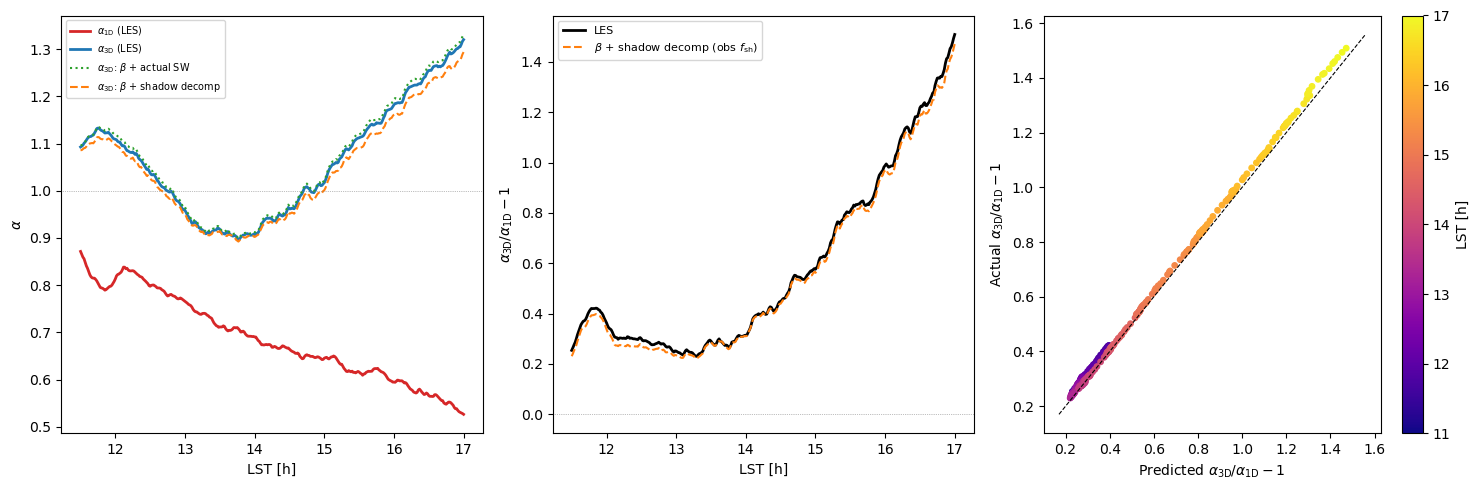

In [22]:
ok_a = win & np.isfinite(alpha_3d_actual) & np.isfinite(alpha_3d_pred) & np.isfinite(alpha_3d_full) & (Q_dm_3d > 0.001)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) Time series
ax = axes[0]
ax.plot(lst[ok_a], alpha_1d_actual[ok_a], 'C3-', lw=2, label=r'$\alpha_{\mathrm{1D}}$ (LES)')
ax.plot(lst[ok_a], alpha_3d_actual[ok_a], 'C0-', lw=2, label=r'$\alpha_{\mathrm{3D}}$ (LES)')
ax.plot(lst[ok_a], alpha_3d_from_sw[ok_a], 'C2:', lw=1.5, label=r'$\alpha_{\mathrm{3D}}$: $\beta$ + actual SW')
ax.plot(lst[ok_a], alpha_3d_pred[ok_a], 'C1--', lw=1.5, label=r'$\alpha_{\mathrm{3D}}$: $\beta$ + shadow decomp')
# ax.plot(lst[ok_a], alpha_3d_full[ok_a], 'C4-.', lw=1.5, label=r'$\alpha_{\mathrm{3D}}$: + predicted $f_{\mathrm{sh}}$')
ax.axhline(1, color='grey', ls=':', lw=0.5)
ax.set(xlabel='LST [h]', ylabel=r'$\alpha$')
ax.legend(fontsize=7)
# ax.set_title(r'$\alpha$ time series')

# (b) Fractional change: alpha_3D/alpha_1D - 1
ax = axes[1]
fc_actual = alpha_3d_actual[ok_a] / alpha_1d_actual[ok_a] - 1
fc_pred = alpha_3d_pred[ok_a] / alpha_1d_pred[ok_a] - 1
fc_full = alpha_3d_full[ok_a] / alpha_1d_pred[ok_a] - 1

ax.plot(lst[ok_a], fc_actual, 'k-', lw=2, label='LES')
ax.plot(lst[ok_a], fc_pred, 'C1--', lw=1.5, label=r'$\beta$ + shadow decomp (obs $f_{\mathrm{sh}}$)')
# ax.plot(lst[ok_a], fc_full, 'C4-.', lw=1.5, label=r'+ predicted $f_{\mathrm{sh}}$')
ax.axhline(0, color='grey', ls=':', lw=0.5)
ax.set(xlabel='LST [h]', ylabel=r'$\alpha_{\mathrm{3D}}/\alpha_{\mathrm{1D}} - 1$')
ax.legend(fontsize=8)
# ax.set_title('Fractional change in growth rate')

# (c) Scatter of fractional change predictions
ax = axes[2]
ok_fc = np.isfinite(fc_actual) & np.isfinite(fc_pred) & np.isfinite(fc_full)
sc = ax.scatter(fc_pred[ok_fc], fc_actual[ok_fc], c=lst[ok_a][ok_fc], s=15,
                cmap='plasma', vmin=11, vmax=17) # label='obs $f_{\\mathrm{sh}}$'
# ax.scatter(fc_full[ok_fc], fc_actual[ok_fc], c='grey', s=8, alpha=0.4,
#            label='predicted $f_{\\mathrm{sh}}$', zorder=1)
lo = min(np.nanmin(fc_pred[ok_fc]), np.nanmin(fc_full[ok_fc]), np.nanmin(fc_actual[ok_fc]))
hi = max(np.nanmax(fc_pred[ok_fc]), np.nanmax(fc_full[ok_fc]), np.nanmax(fc_actual[ok_fc]))
lims = [lo - 0.05, hi + 0.05]
ax.plot(lims, lims, 'k--', lw=0.8)

# r_p, _ = pearsonr(fc_pred[ok_fc], fc_actual[ok_fc])
# r_f, _ = pearsonr(fc_full[ok_fc], fc_actual[ok_fc])
# ax.set_title(f'obs: r={r_p:.3f}\npred: r={r_f:.3f}')

ax.set(xlabel='Predicted $\\alpha_{\\mathrm{3D}}/\\alpha_{\\mathrm{1D}} - 1$',
       ylabel='Actual $\\alpha_{\\mathrm{3D}}/\\alpha_{\\mathrm{1D}} - 1$')
# ax.legend(fontsize=8, loc='upper left')
fig.colorbar(sc, ax=ax, label='LST [h]')

fig.tight_layout()


In [15]:
# ── Summary ──────────────────────────────────────────────────────────────────
ok_s = ok_a & np.isfinite(alpha_1d_pred) & np.isfinite(alpha_3d_full)

def alpha_stats(pred, actual, label):
    finite = np.isfinite(pred) & np.isfinite(actual)
    r, _ = pearsonr(pred[finite], actual[finite])
    bias = np.mean(pred[finite] - actual[finite])
    rmse = np.sqrt(np.mean((pred[finite] - actual[finite])**2))
    print(f'{label:<60} r={r:.3f}  bias={bias:+.4f}  RMSE={rmse:.4f}')

print('Predicting alpha_3D:\n')
alpha_stats(alpha_3d_from_sw[ok_s], alpha_3d_actual[ok_s],
            'beta framework + actual SW (baseline)')
alpha_stats(alpha_3d_pred[ok_s], alpha_3d_actual[ok_s],
            '+ shadow decomp (observed f_sh)')
alpha_stats(alpha_3d_full[ok_s], alpha_3d_actual[ok_s],
            '+ predicted f_sh (fully closed)')

# Fractional change stats
print('\nPredicting alpha_3D/alpha_1D - 1:\n')
fc_a = alpha_3d_actual[ok_s] / alpha_1d_actual[ok_s] - 1
fc_p = alpha_3d_pred[ok_s] / alpha_1d_pred[ok_s] - 1
fc_f = alpha_3d_full[ok_s] / alpha_1d_pred[ok_s] - 1
alpha_stats(fc_p, fc_a, 'obs f_sh')
alpha_stats(fc_f, fc_a, 'predicted f_sh')

print(f'\n--- Component means ---')
print(f'  f_sh obs:  {np.nanmean(f_sh[ok_s]):.3f}')
print(f'  f_sh pred: {np.nanmean(f_sh_pred_cass[ok_s]):.3f}')
print(f'  f_dom:     {np.nanmean(f_sh_dom[ok_s]):.3f}')
print(f'  cf:        {np.nanmean(cf[ok_s]):.3f}')
print(f'  mu0:       {np.nanmean(mu0[ok_s]):.3f}')


Predicting alpha_3D:

beta framework + actual SW (baseline)                        r=1.000  bias=+0.0070  RMSE=0.0075
+ shadow decomp (observed f_sh)                              r=1.000  bias=-0.0144  RMSE=0.0162
+ predicted f_sh (fully closed)                              r=0.971  bias=-0.0406  RMSE=0.0903

Predicting alpha_3D/alpha_1D - 1:

obs f_sh                                                     r=1.000  bias=-0.0189  RMSE=0.0216
predicted f_sh                                               r=0.968  bias=-0.0657  RMSE=0.1460

--- Component means ---
  f_sh obs:  0.222
  f_sh pred: 0.245
  f_dom:     0.176
  cf:        0.138
  mu0:       0.777
